In [31]:
!pip install yfinance pandas boto3

In [32]:
import yfinance as yf
import pandas as pd

# ==========================================
# 1. PARAMETER DATA
# ==========================================
ticker = "MEDC.JK"
periode = "5y" # Mengambil data 5 tahun terakhir untuk menangkap tren makro

print(f"Mulai mengunduh data saham {ticker} dari Yahoo Finance API...")

# ==========================================
# 2. PROSES UNDUH DATA
# ==========================================
data = yf.download(ticker, period=periode)

# Mengecek apakah data berhasil ditarik
if data.empty:
    print("Gagal menarik data. Cek koneksi internet atau simbol ticker.")
else:
    print("Data berhasil diunduh!")

    # ==========================================
    # 3. PEMBERSIHAN DATA (CLEANING)
    # ==========================================
    # Menghapus baris yang memiliki nilai kosong
    data_clean = data.dropna()

    # Mengembalikan 'Date' dari index menjadi kolom biasa
    data_clean = data_clean.reset_index()

    # Memilih kolom esensial yang umum digunakan untuk forecasting
    kolom_utama = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
    data_final = data_clean[kolom_utama]

    # ==========================================
    # 4. INSPEKSI ANALITIK
    # ==========================================
    print("\n--- 5 Baris Pertama Data ---")
    print(data_final.head())

    print("\n--- Info Struktur Data ---")
    print(data_final.info())

    print("\n--- Ringkasan Statistik ---")
    print(data_final.describe())

    # ==========================================
    # 5. SIMPAN KE LOKAL (UNTUK UJI COBA)
    # ==========================================
    nama_file = "medc.csv"
    data_final.to_csv(nama_file, index=False)
    print(f"\nData berhasil disimpan secara lokal dengan nama: {nama_file}")

[*********************100%***********************]  1 of 1 completed

Mulai mengunduh data saham MEDC.JK dari Yahoo Finance API...
Data berhasil diunduh!

--- 5 Baris Pertama Data ---
Price        Date        Open        High         Low       Close    Volume
Ticker                MEDC.JK     MEDC.JK     MEDC.JK     MEDC.JK   MEDC.JK
0      2021-04-13  483.732502  483.732502  471.113394  475.319763  17371600
1      2021-04-14  483.732504  487.938873  475.319764  487.938873  14964900
2      2021-04-15  500.557982  504.764352  483.732504  487.938873  22801200
3      2021-04-16  487.938914  496.351654  483.732544  483.732544  16677600
4      2021-04-19  483.732502  487.938872  475.319763  475.319763  16503300

--- Info Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   (Date, )           1200 non-null   datetime64[ns]
 1   (Open, MEDC.JK)    1200 non-null   float64       


In [33]:
data_final

Price,Date,Open,High,Low,Close,Volume
Ticker,,MEDC.JK,MEDC.JK,MEDC.JK,MEDC.JK,MEDC.JK
0,2021-04-13,483.732502,483.732502,471.113394,475.319763,17371600
1,2021-04-14,483.732504,487.938873,475.319764,487.938873,14964900
2,2021-04-15,500.557982,504.764352,483.732504,487.938873,22801200
3,2021-04-16,487.938914,496.351654,483.732544,483.732544,16677600
4,2021-04-19,483.732502,487.938872,475.319763,475.319763,16503300
...,...,...,...,...,...,...
1195,2026-04-07,1600.000000,1660.000000,1600.000000,1630.000000,84524400
1196,2026-04-08,1570.000000,1570.000000,1475.000000,1555.000000,259045700
1197,2026-04-09,1580.000000,1615.000000,1545.000000,1550.000000,129946100


In [34]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   (Date, )           1200 non-null   datetime64[ns]
 1   (Open, MEDC.JK)    1200 non-null   float64       
 2   (High, MEDC.JK)    1200 non-null   float64       
 3   (Low, MEDC.JK)     1200 non-null   float64       
 4   (Close, MEDC.JK)   1200 non-null   float64       
 5   (Volume, MEDC.JK)  1200 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 56.4 KB


In [35]:
import boto3

s3_client = boto3.client('s3')
bucket_name = "medc-energy-forecasting"

# Aktifkan versioning
s3_client.put_bucket_versioning(
    Bucket=bucket_name,
    VersioningConfiguration={'Status': 'Enabled'}
)
print("Versioning enabled!")

# Verifikasi
response = s3_client.get_bucket_versioning(Bucket=bucket_name)
print(f"Versioning status: {response.get('Status', 'Disabled')}")

Versioning enabled!
Versioning status: Enabled


In [36]:
# Export Data CSV
data_final.to_csv("medc.csv", index=False)

In [37]:
!pip install yfinance boto3 pandas matplotlib -q

import yfinance as yf
import pandas as pd
import os
import boto3
import matplotlib.pyplot as plt

In [38]:
s3 = boto3.client(
    's3',
    region_name='ap-southeast-1',
    aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('AWS_SECRET_ACCESS_KEY')
)

BUCKET_NAME = "medc-energy-forecasting"


In [39]:
s3.download_file(BUCKET_NAME, "raw/medc.csv", "verify_data.csv")
df_verify = pd.read_csv("verify_data.csv")
print("\n Verifikasi baca dari S3:")
print(df_verify.head())


 Verifikasi baca dari S3:
         Date                Open                High                Low  \
0         NaN             MEDC.JK             MEDC.JK            MEDC.JK   
1  2021-04-13   483.7325023549848   483.7325023549848  471.1133935978982   
2  2021-04-14   483.7325339481748  487.93890380859375   475.319794227337   
3  2021-04-15   500.5580133898505  504.76438325026936  483.7325339481748   
4  2021-04-16  487.93888310971465  496.35162247367526  483.7325134277344   

                Close    Volume  
0             MEDC.JK   MEDC.JK  
1  475.31976318359375  17371600  
2  487.93890380859375  14964900  
3  487.93890380859375  22801200  
4   483.7325134277344  16677600  


Price        Date  MEDC_Close
Ticker                MEDC.JK
0      2021-04-13  475.319794
1      2021-04-14  487.938873
2      2021-04-15  487.938873
3      2021-04-16  483.732483
4      2021-04-19  475.319794


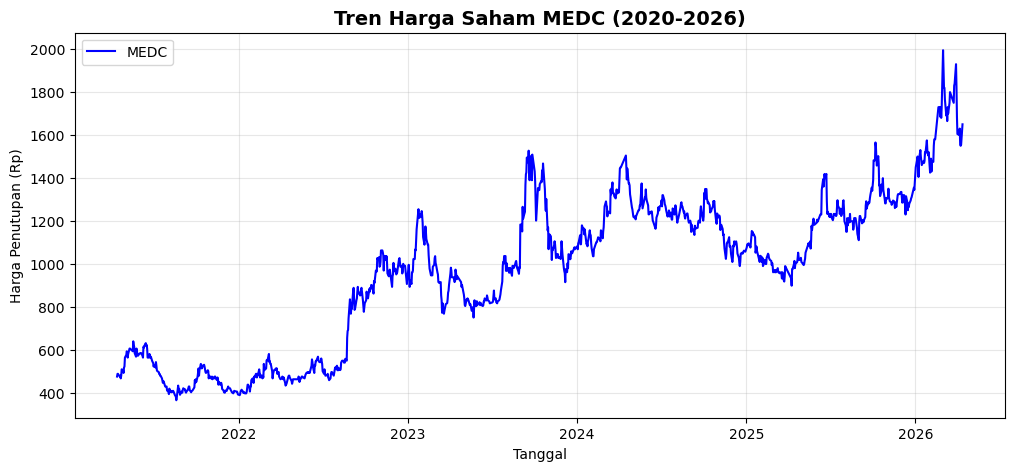

In [40]:
# Reset index dengan drop=True (menghapus index lama tanpa menyimpannya)
# Pastikan df_final sudah didefinisikan sebelumnya
if 'df_final' not in locals():
    df_final = data_final.copy()

medc = df_final.reset_index(drop=True)

# Ambil kolom yang diperlukan (hanya Date dan Close)
medc_simple = medc[["Date", "Close"]].copy()

# Rename kolom Close menjadi MEDC_Close
medc_simple = medc_simple.rename(columns={"Close": "MEDC_Close"})

# Tidak perlu merge, langsung gunakan medc_simple sebagai df
df = medc_simple.copy()

print(df.head())

# Visualisasi
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["MEDC_Close"], color='blue', linewidth=1.5)
plt.title("Tren Harga Saham MEDC (2020-2026)", fontsize=14, fontweight='bold')
plt.xlabel("Tanggal")
plt.ylabel("Harga Penutupan (Rp)")
plt.legend(["MEDC"])
plt.grid(True, alpha=0.3)
plt.show()

# TAHAP PROCESSING

In [41]:
s3.download_file(BUCKET_NAME, "raw/medc.csv", "raw_data_from_s3.csv")

In [42]:
df_raw = pd.read_csv("raw_data_from_s3.csv", skiprows=[1])
print(df_raw.head())

print(f"\n Informasi Data:")
print(f"   - Jumlah baris: {len(df_raw)}")
print(f"   - Jumlah kolom: {len(df_raw.columns)}")
print(f"   - Kolom: {df_raw.columns.tolist()}")

         Date        Open        High         Low       Close    Volume
0  2021-04-13  483.732502  483.732502  471.113394  475.319763  17371600
1  2021-04-14  483.732534  487.938904  475.319794  487.938904  14964900
2  2021-04-15  500.558013  504.764383  483.732534  487.938904  22801200
3  2021-04-16  487.938883  496.351622  483.732513  483.732513  16677600
4  2021-04-19  483.732502  487.938872  475.319763  475.319763  16503300

 Informasi Data:
   - Jumlah baris: 1200
   - Jumlah kolom: 6
   - Kolom: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']


In [43]:
# ==========================================
# CEK STRUKTUR FILE CSV DARI S3
# ==========================================

# Baca data dari S3
s3.download_file(BUCKET_NAME, "raw/medc.csv", "raw_data_from_s3.csv")

# Baca CSV tanpa skiprows dulu untuk lihat struktur
df_check = pd.read_csv("raw_data_from_s3.csv")
print("Shape file:", df_check.shape)
print("Kolom yang tersedia:", df_check.columns.tolist())
print("\n5 baris pertama:")
print(df_check.head())

Shape file: (1201, 6)
Kolom yang tersedia: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

5 baris pertama:
         Date                Open                High                Low  \
0         NaN             MEDC.JK             MEDC.JK            MEDC.JK   
1  2021-04-13   483.7325023549848   483.7325023549848  471.1133935978982   
2  2021-04-14   483.7325339481748  487.93890380859375   475.319794227337   
3  2021-04-15   500.5580133898505  504.76438325026936  483.7325339481748   
4  2021-04-16  487.93888310971465  496.35162247367526  483.7325134277344   

                Close    Volume  
0             MEDC.JK   MEDC.JK  
1  475.31976318359375  17371600  
2  487.93890380859375  14964900  
3  487.93890380859375  22801200  
4   483.7325134277344  16677600  


In [44]:
# ==========================================
# CLEANING DATA MEDC (SEDERHANA)
# ==========================================

# Baca data dari S3 (langsung ambil kolom yang diperlukan)
df_medc = pd.read_csv(
    "raw_data_from_s3.csv", 
    skiprows=1,  # Skip baris pertama (MultiIndex)
    usecols=[0, 1],  # Ambil kolom 0 (Date) dan kolom 1 (Close)
    names=["Date", "MEDC_Close"]  # Beri nama kolom
)

# Konversi Date ke datetime
df_medc["Date"] = pd.to_datetime(df_medc["Date"])

# Bersihkan data
df_medc = df_medc.dropna()
df_medc = df_medc.drop_duplicates(subset=["Date"])
df_medc = df_medc.sort_values("Date").reset_index(drop=True)

print(f"Data MEDC siap: {len(df_medc)} baris")
print(f"Periode: {df_medc['Date'].min()} s/d {df_medc['Date'].max()}")
print("\n5 baris pertama:")
print(df_medc.head())

Data MEDC siap: 1200 baris
Periode: 2021-04-13 00:00:00 s/d 2026-04-13 00:00:00

5 baris pertama:
        Date          MEDC_Close
0 2021-04-13   483.7325023549848
1 2021-04-14   483.7325339481748
2 2021-04-15   500.5580133898505
3 2021-04-16  487.93888310971465
4 2021-04-19   483.7325023549848


In [45]:
print(f"Setelah cleaning: {len(df_raw)} baris")
print(f"Periode: {df_raw['Date'].min()} s/d {df_raw['Date'].max()}")

Setelah cleaning: 1200 baris
Periode: 2021-04-13 s/d 2026-04-13


In [46]:
df = df_raw.copy()

In [47]:
# ==========================================
# BACA DATA MEDC DARI S3 (VERSI RINGKAS)
# ==========================================

# Baca data dari S3
s3.download_file(BUCKET_NAME, "raw/medc.csv", "raw_data_from_s3.csv")

# Baca CSV dan skip baris pertama (yang berisi "MEDC.JK")
df_raw = pd.read_csv("raw_data_from_s3.csv", skiprows=[1])

# Beri nama kolom
df_raw.columns = ["Date", "Open", "High", "Low", "Close", "Volume"]

# Konversi tipe data
df_raw["Date"] = pd.to_datetime(df_raw["Date"])
for col in ["Open", "High", "Low", "Close", "Volume"]:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Ambil hanya Date dan Close
df = df_raw[["Date", "Close"]].copy()
df = df.rename(columns={"Close": "MEDC_Close"})

# Bersihkan
df = df.dropna().drop_duplicates(subset=["Date"]).sort_values("Date").reset_index(drop=True)

print(f" Data MEDC siap: {len(df)} baris")
print(f" Periode: {df['Date'].min().date()} s/d {df['Date'].max().date()}")
print("\n 5 baris pertama:")
print(df.head())

 Data MEDC siap: 1200 baris
 Periode: 2021-04-13 s/d 2026-04-13

 5 baris pertama:
        Date  MEDC_Close
0 2021-04-13  475.319763
1 2021-04-14  487.938904
2 2021-04-15  487.938904
3 2021-04-16  483.732513
4 2021-04-19  475.319763


In [48]:
# ==========================================
# FEATURE ENGINEERING & ANALISIS
# ==========================================

# Return Harian (% perubahan)
df["MEDC_Return"] = df["MEDC_Close"].pct_change() * 100

# Return Kumulatif
df["MEDC_CumReturn"] = (1 + df["MEDC_Return"]/100).cumprod()

# Moving Average
df["MEDC_MA7"] = df["MEDC_Close"].rolling(window=7).mean()
df["MEDC_MA30"] = df["MEDC_Close"].rolling(window=30).mean()

# Volatilitas
df["MEDC_Volatility"] = df["MEDC_Return"].rolling(window=30).std()

# Deteksi Anomali (IQR)
Q1 = df["MEDC_Return"].quantile(0.25)
Q3 = df["MEDC_Return"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["Is_Anomaly"] = ((df["MEDC_Return"] < lower_bound) | 
                     (df["MEDC_Return"] > upper_bound)).astype(int)

# Statistik ringkasan
print("\n" + "="*50)
print("RINGKASAN STATISTIK MEDC")
print("="*50)
print(f"Total data points: {len(df)}")
print(f"Periode: {df['Date'].min().date()} s/d {df['Date'].max().date()}")
print(f"\nHarga MEDC:")
print(f"  - Mean: Rp {df['MEDC_Close'].mean():.2f}")
print(f"  - Std Dev: Rp {df['MEDC_Close'].std():.2f}")
print(f"  - Min: Rp {df['MEDC_Close'].min():.2f}")
print(f"  - Max: Rp {df['MEDC_Close'].max():.2f}")
print(f"\nReturn MEDC:")
print(f"  - Mean Return: {df['MEDC_Return'].mean():.4f}%")
print(f"  - Volatilitas (avg): {df['MEDC_Volatility'].mean():.4f}")
print(f"\nDeteksi Anomali:")
print(f"  - Jumlah anomali: {df['Is_Anomaly'].sum()} hari")
print(f"  - Persentase anomali: {(df['Is_Anomaly'].sum()/len(df))*100:.2f}%")


RINGKASAN STATISTIK MEDC
Total data points: 1200
Periode: 2021-04-13 s/d 2026-04-13

Harga MEDC:
  - Mean: Rp 965.74
  - Std Dev: Rp 353.15
  - Min: Rp 365.11
  - Max: Rp 1995.00

Return MEDC:
  - Mean Return: 0.1532%
  - Volatilitas (avg): 3.0274

Deteksi Anomali:
  - Jumlah anomali: 36 hari
  - Persentase anomali: 3.00%


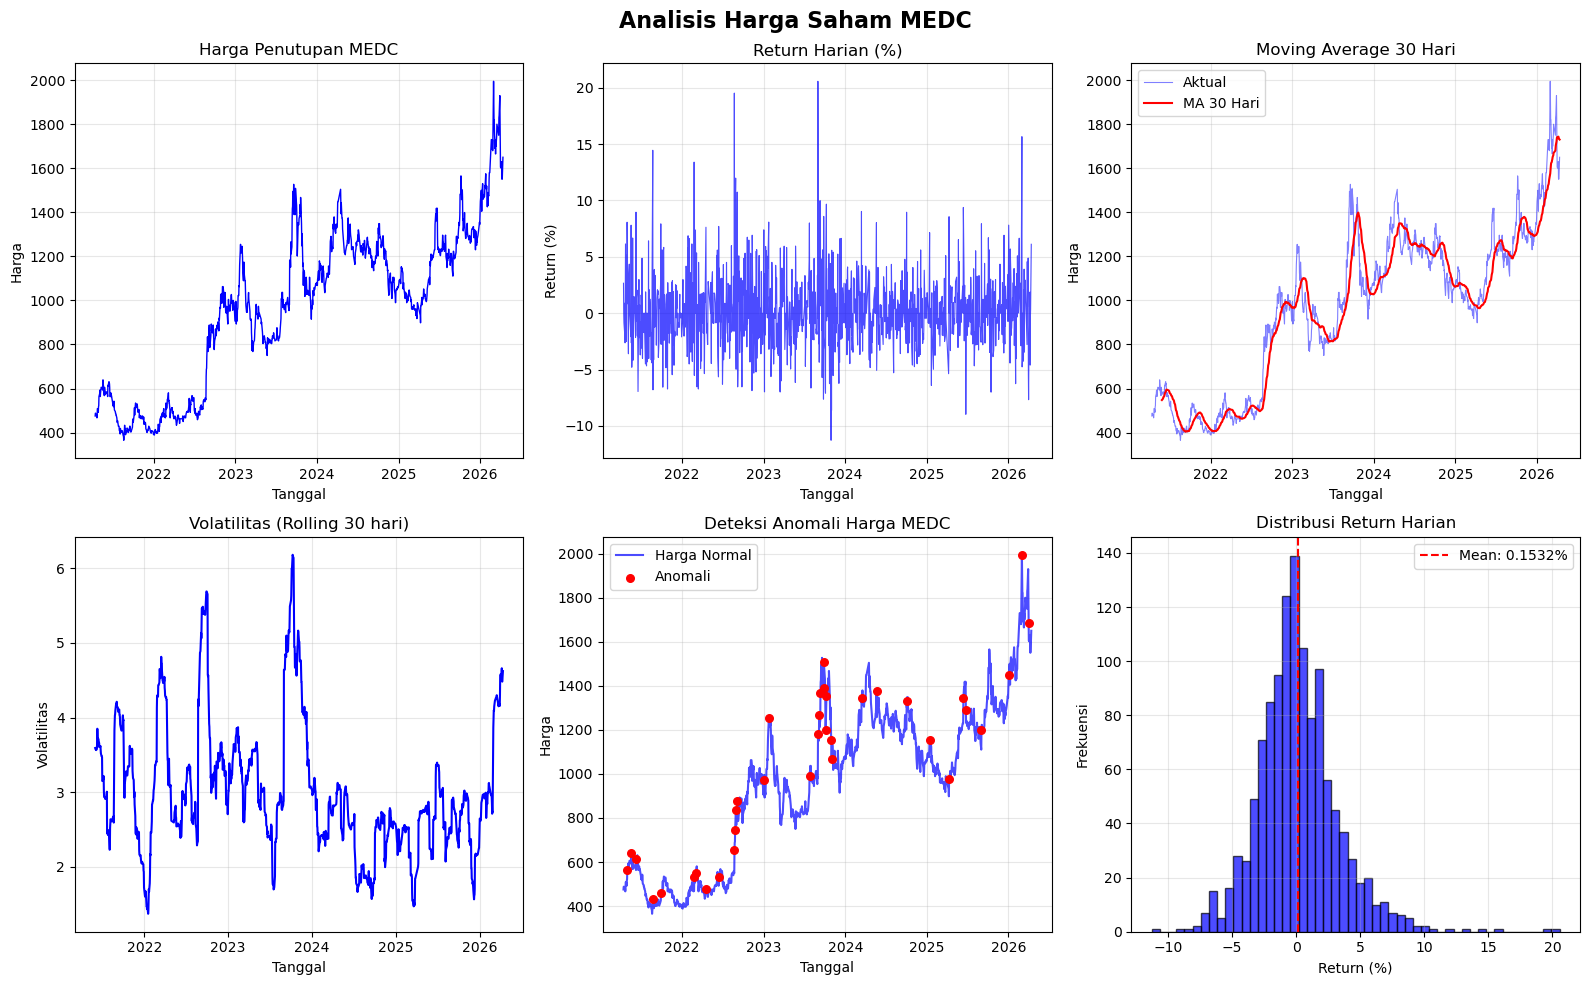

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Analisis Harga Saham MEDC", fontsize=16, fontweight='bold')

# Plot 1: Harga Close
axes[0,0].plot(df["Date"], df["MEDC_Close"], color="blue", linewidth=1)
axes[0,0].set_title("Harga Penutupan MEDC")
axes[0,0].set_xlabel("Tanggal")
axes[0,0].set_ylabel("Harga")
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Return Harian
axes[0,1].plot(df["Date"], df["MEDC_Return"], color="blue", alpha=0.7, linewidth=0.8)
axes[0,1].set_title("Return Harian (%)")
axes[0,1].set_xlabel("Tanggal")
axes[0,1].set_ylabel("Return (%)")
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Moving Average
axes[0,2].plot(df["Date"], df["MEDC_Close"], label="Aktual", color="blue", alpha=0.5, linewidth=0.8)
axes[0,2].plot(df["Date"], df["MEDC_MA30"], label="MA 30 Hari", color="red", linewidth=1.5)
axes[0,2].set_title("Moving Average 30 Hari")
axes[0,2].set_xlabel("Tanggal")
axes[0,2].set_ylabel("Harga")
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Plot 4: Volatilitas
axes[1,0].plot(df["Date"], df["MEDC_Volatility"], color="blue")
axes[1,0].set_title("Volatilitas (Rolling 30 hari)")
axes[1,0].set_xlabel("Tanggal")
axes[1,0].set_ylabel("Volatilitas")
axes[1,0].grid(True, alpha=0.3)

# Plot 5: Deteksi Anomali
anomaly_dates = df[df["Is_Anomaly"] == 1]
axes[1,1].plot(df["Date"], df["MEDC_Close"], label="Harga Normal", color="blue", alpha=0.7)
axes[1,1].scatter(anomaly_dates["Date"], anomaly_dates["MEDC_Close"],
                   color="red", s=30, label="Anomali", zorder=5)
axes[1,1].set_title("Deteksi Anomali Harga MEDC")
axes[1,1].set_xlabel("Tanggal")
axes[1,1].set_ylabel("Harga")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Distribusi Return (Histogram)
axes[1,2].hist(df["MEDC_Return"].dropna(), bins=50, color="blue", alpha=0.7, edgecolor='black')
axes[1,2].set_title("Distribusi Return Harian")
axes[1,2].set_xlabel("Return (%)")
axes[1,2].set_ylabel("Frekuensi")
axes[1,2].axvline(x=df["MEDC_Return"].mean(), color='red', linestyle='--', label=f'Mean: {df["MEDC_Return"].mean():.4f}%')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dashboard_medc.png", dpi=150, bbox_inches='tight')
plt.show()

In [50]:
print("\n" + "="*50)
print("RINGKASAN STATISTIK DESKRIPTIF - SAHAM MEDC")
print("="*50)

# Hitung metrik tambahan
total_return = ((df['MEDC_Close'].iloc[-1] / df['MEDC_Close'].iloc[0]) - 1) * 100
max_drawdown = ((df['MEDC_Close'].cummax() - df['MEDC_Close']) / df['MEDC_Close'].cummax() * 100).max()

summary_stats = {
    "Metric": [
        " Total Data Points",
        " Start Date",
        " End Date",
        " MEDC - Mean Price",
        " MEDC - Max Price",
        " MEDC - Min Price",
        " MEDC - Std Dev",
        " Total Anomaly Days",
        " Anomaly Percentage",
        " MEDC - Mean Return (%)",
        " MEDC - Volatility (avg)",
        " MEDC - Cumulative Return (%)",
        " MEDC - Max Drawdown (%)"
    ],
    "Value": [
        f"{len(df):,}",
        df["Date"].min().strftime("%Y-%m-%d"),
        df["Date"].max().strftime("%Y-%m-%d"),
        f"Rp {df['MEDC_Close'].mean():.2f}",
        f"Rp {df['MEDC_Close'].max():.2f}",
        f"Rp {df['MEDC_Close'].min():.2f}",
        f"Rp {df['MEDC_Close'].std():.2f}",
        f"{df['Is_Anomaly'].sum():,}",
        f"{(df['Is_Anomaly'].sum()/len(df))*100:.2f}%",
        f"{df['MEDC_Return'].mean():.4f}%",
        f"{df['MEDC_Volatility'].mean():.4f}",
        f"{total_return:.2f}%",
        f"{max_drawdown:.2f}%"
    ]
}

summary_df = pd.DataFrame(summary_stats)
summary_df


RINGKASAN STATISTIK DESKRIPTIF - SAHAM MEDC


,Metric,Value
0,Total Data Points,"1,200"
1,Start Date,2021-04-13
2,End Date,2026-04-13
3,MEDC - Mean Price,Rp 965.74
4,MEDC - Max Price,Rp 1995.00
5,MEDC - Min Price,Rp 365.11
6,MEDC - Std Dev,Rp 353.15
7,Total Anomaly Days,36
8,Anomaly Percentage,3.00%
9,MEDC - Mean Return (%),0.1532%


# SIMPAN DATA PROCESSED

In [51]:
# ==========================================
# SIMPAN DATA HASIL PROCESSING KE S3
# ==========================================

# Simpan data hasil processing (full dataset)
df.to_csv("processed_energy_data.csv", index=False)
s3.upload_file("processed_energy_data.csv", BUCKET_NAME, "processed/processed_energy_data.csv")
print(" Data processed berhasil diupload ke S3: processed/processed_energy_data.csv")

# Simpan ringkasan statistik
summary_df.to_csv("summary_statistics.csv", index=False)
s3.upload_file("summary_statistics.csv", BUCKET_NAME, "processed/summary_statistics.csv")
print(" Ringkasan statistik berhasil diupload ke S3: processed/summary_statistics.csv")

# Upload gambar dashboard
s3.upload_file("dashboard_medc.png", BUCKET_NAME, "processed/dashboard_medc.png")
print(" Dashboard gambar berhasil diupload ke S3: processed/dashboard_medc.png")

# Simpan data anomali terpisah (hanya MEDC)
anomaly_df = df[df["Is_Anomaly"] == 1][["Date", "MEDC_Close", "MEDC_Return"]]
anomaly_df.to_csv("anomaly_detection.csv", index=False)
s3.upload_file("anomaly_detection.csv", BUCKET_NAME, "processed/anomaly_detection.csv")
print(" Data anomali berhasil diupload ke S3: processed/anomaly_detection.csv")

# ==========================================
# VERIFIKASI SEMUA FILE TELAH TERUPLOAD
# ==========================================
print("\n" + "="*50)
print("VERIFIKASI FILE DI S3 BUCKET")
print("="*50)

# List semua file di bucket
response = s3.list_objects_v2(Bucket=BUCKET_NAME)

if 'Contents' in response:
    print(f"\nFile dalam bucket '{BUCKET_NAME}':")
    for obj in response['Contents']:
        print(f"   {obj['Key']} ({obj['Size']:,} bytes)")
else:
    print("Bucket kosong atau tidak dapat diakses")

 Data processed berhasil diupload ke S3: processed/processed_energy_data.csv
 Ringkasan statistik berhasil diupload ke S3: processed/summary_statistics.csv
 Dashboard gambar berhasil diupload ke S3: processed/dashboard_medc.png
 Data anomali berhasil diupload ke S3: processed/anomaly_detection.csv

VERIFIKASI FILE DI S3 BUCKET

File dalam bucket 'medc-energy-forecasting':
   processed/ (0 bytes)
   processed/anomaly_detection.csv (1,687 bytes)
   processed/dashboard_analysis.png (441,677 bytes)
   processed/dashboard_medc.png (331,387 bytes)
   processed/medc_future_forecast.csv (7,627 bytes)
   processed/processed_energy_data.csv (144,312 bytes)
   processed/summary_statistics.csv (379 bytes)
   raw/ (0 bytes)
   raw/energy_data.csv (107,420 bytes)
   raw/medc.csv (107,393 bytes)


In [52]:
s3.download_file(BUCKET_NAME, "processed/processed_energy_data.csv", "verify_final.csv")
df_final_verify = pd.read_csv("verify_final.csv")
print(f"Berhasil baca dari S3: {len(df_final_verify)} baris, {len(df_final_verify.columns)} kolom")

Berhasil baca dari S3: 1200 baris, 8 kolom


In [54]:
s3.download_file(BUCKET_NAME, "processed/anomaly_detection.csv", "anomaly_detection.csv")

# Baca file CSV
anomaly_df = pd.read_csv("anomaly_detection.csv")

# Konversi Date ke datetime
anomaly_df["Date"] = pd.to_datetime(anomaly_df["Date"])

print(f" Data anomali berhasil dibaca dari S3!")
print(f" Total hari anomali: {len(anomaly_df)} hari")
print(f" Periode anomali: {anomaly_df['Date'].min().date()} s/d {anomaly_df['Date'].max().date()}")
print("\n data anomali teratas:")
print(anomaly_df)

# Statistik lengkap
print("\n" + "="*60)
print("STATISTIK LENGKAP DATA ANOMALI")
print("="*60)
print(f"Total hari anomali: {len(anomaly_df)}")
print(f"Rentang tanggal: {anomaly_df['Date'].min().date()} - {anomaly_df['Date'].max().date()}")
print(f"\n Statistik Harga Saat Anomali:")
print(f"   - Rata-rata harga: Rp {anomaly_df['MEDC_Close'].mean():,.2f}")
print(f"   - Harga terendah: Rp {anomaly_df['MEDC_Close'].min():,.2f}")
print(f"   - Harga tertinggi: Rp {anomaly_df['MEDC_Close'].max():,.2f}")
print(f"\n Statistik Return Saat Anomali:")
print(f"   - Rata-rata return: {anomaly_df['MEDC_Return'].mean():.4f}%")
print(f"   - Return terendah: {anomaly_df['MEDC_Return'].min():.4f}%")
print(f"   - Return tertinggi: {anomaly_df['MEDC_Return'].max():.4f}%")

 Data anomali berhasil dibaca dari S3!
 Total hari anomali: 36 hari
 Periode anomali: 2021-04-30 s/d 2026-04-01

 data anomali teratas:
         Date   MEDC_Close  MEDC_Return
0  2021-04-30   563.653442     8.064497
1  2021-05-18   639.368103     7.801400
2  2021-06-09   614.129944     8.955237
3  2021-08-23   433.256073    14.444443
4  2021-09-28   458.494263     7.920788
5  2022-02-24   534.208984    13.392865
6  2022-03-02   551.034485     7.377068
7  2022-04-18   475.319763     7.619044
8  2022-06-14   530.002625     7.692321
9  2022-08-23   656.343262    19.512195
10 2022-08-26   745.641724     7.741944
11 2022-08-29   834.940125    11.976047
12 2022-09-05   875.124268    10.734449
13 2023-01-02   973.352539     7.389157
14 2023-01-24  1254.642578     8.076933
15 2023-07-25   990.606506     8.000004
16 2023-09-01  1183.224243    20.560730
17 2023-09-06  1265.774902     9.960152
18 2023-09-12  1366.670044     9.963099
19 2023-09-26  1389.600830    -7.621946
20 2023-09-27  1508.8404

In [55]:
anomaly_df

,Date,MEDC_Close,MEDC_Return
0,2021-04-30,563.653442,8.064497
1,2021-05-18,639.368103,7.801400
2,2021-06-09,614.129944,8.955237
3,2021-08-23,433.256073,14.444443
4,2021-09-28,458.494263,7.920788
5,2022-02-24,534.208984,13.392865
6,2022-03-02,551.034485,7.377068
7,2022-04-18,475.319763,7.619044
8,2022-06-14,530.002625,7.692321
9,2022-08-23,656.343262,19.512195


In [56]:
# ==========================================
# BACA DAN VERIFIKASI DATA MEDC SAJA DARI S3
# ==========================================

# Download file dari S3
s3.download_file(BUCKET_NAME, "processed/processed_energy_data.csv", "verify_final.csv")

# Baca file CSV (hanya kolom Date dan MEDC_Close)
df_final_verify = pd.read_csv("verify_final.csv", usecols=["Date", "MEDC_Close"])

# Konversi Date ke datetime
df_final_verify["Date"] = pd.to_datetime(df_final_verify["Date"])

print(f" Berhasil baca dari S3: {len(df_final_verify)} baris, {len(df_final_verify.columns)} kolom")
print(f"   Kolom: {df_final_verify.columns.tolist()}")
print(f"   Periode: {df_final_verify['Date'].min()} s/d {df_final_verify['Date'].max()}")
print("\n5 baris terakhir:")
df_final_verify.tail()

 Berhasil baca dari S3: 1200 baris, 2 kolom
   Kolom: ['Date', 'MEDC_Close']
   Periode: 2021-04-13 00:00:00 s/d 2026-04-13 00:00:00

5 baris terakhir:


,Date,MEDC_Close
1195,2026-04-07,1630.0
1196,2026-04-08,1555.0
1197,2026-04-09,1550.0
1198,2026-04-10,1555.0
1199,2026-04-13,1650.0


In [57]:
df_final_verify.tail()

,Date,MEDC_Close
1195,2026-04-07,1630.0
1196,2026-04-08,1555.0
1197,2026-04-09,1550.0
1198,2026-04-10,1555.0
1199,2026-04-13,1650.0


# FORECASTING

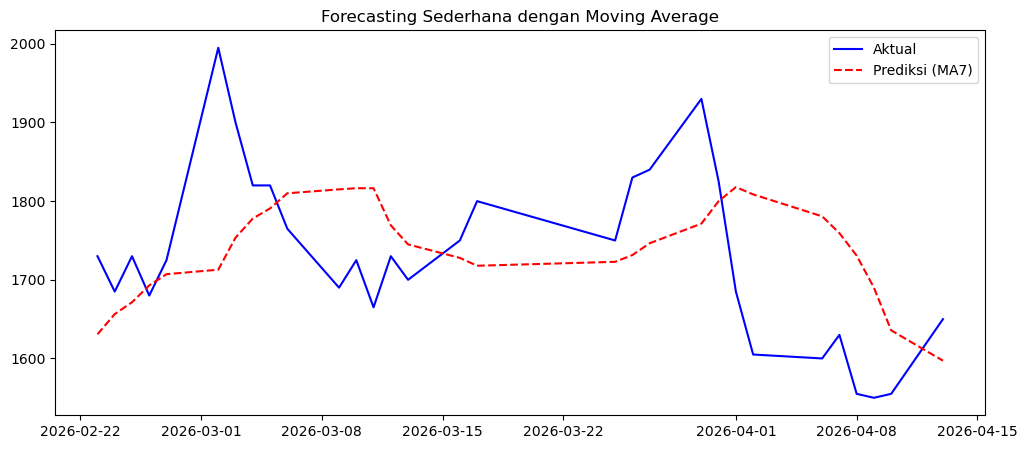

In [58]:
# Prediksi harga 7 hari ke depan dengan MA7
df["MEDC_MA7"] = df["MEDC_Close"].rolling(window=7).mean()
df["MEDC_Prediction_NextDay"] = df["MEDC_MA7"].shift(1)

# Visualisasi prediksi vs aktual
plt.figure(figsize=(12,5))
plt.plot(df["Date"][-30:], df["MEDC_Close"][-30:], label="Aktual", color="blue")
plt.plot(df["Date"][-30:], df["MEDC_Prediction_NextDay"][-30:], label="Prediksi (MA7)", color="red", linestyle="--")
plt.title("Forecasting Sederhana dengan Moving Average")
plt.legend()
plt.show()

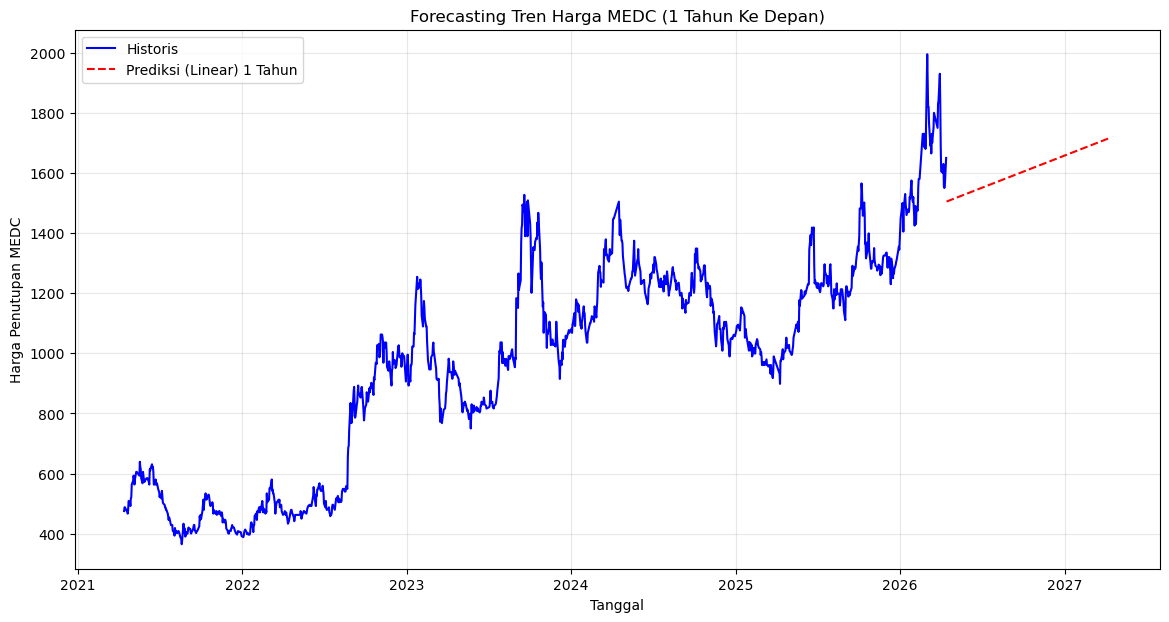

In [59]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pandas as pd

# Pastikan kolom 'Date' adalah datetime
# Jika df sudah memiliki 'Date_Num' dari eksekusi sebelumnya, tidak perlu dihitung ulang
if 'Date_Num' not in df.columns:
    df["Date_Num"] = (df["Date"] - df["Date"].min()).dt.days

# Latih model
model = LinearRegression()
model.fit(df[["Date_Num"]].values, df["MEDC_Close"].values)

# Prediksi 365 hari ke depan (satu tahun)
# future_dates dimulai dari satu hari setelah tanggal terakhir di df
future_dates = pd.date_range(df["Date"].max() + pd.Timedelta(days=1), periods=365, freq='D')
future_days = (future_dates - df["Date"].min()).days.values.reshape(-1, 1)
future_prices = model.predict(future_days)

# Visualisasi
plt.figure(figsize=(14,7))
plt.plot(df["Date"], df["MEDC_Close"], label="Historis", color="blue")
plt.plot(future_dates, future_prices, label="Prediksi (Linear) 1 Tahun", color="red", linestyle="--")
plt.title("Forecasting Tren Harga MEDC (1 Tahun Ke Depan)")
plt.xlabel("Tanggal")
plt.ylabel("Harga Penutupan MEDC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [68]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi training dan testing set
# Kita akan menggunakan 80% data untuk training dan 20% untuk testing
train_size = int(len(data_scaled) * 0.8)

# X dan y sudah dalam bentuk sequence yang benar
X_train, X_test = X[0:train_size-look_back], X[train_size-look_back:len(X)]
y_train, y_test = y[0:train_size-look_back], y[train_size-look_back:len(y)]

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_test: {y_test.shape}")

Ukuran X_train: (900, 60, 1)
Ukuran y_train: (900,)
Ukuran X_test: (240, 60, 1)
Ukuran y_test: (240,)


In [69]:
# Install KerasTuner
!pip install keras-tuner -q

In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

# Fungsi untuk membangun model LSTM dengan hyperparameter yang dapat disetel
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('lstm_units_1', min_value=50, max_value=200, step=50),
                     return_sequences=True, input_shape=(look_back, 1)))
    model.add(Dropout(hp.Float('dropout_1', min_value=0.0, max_value=0.5, step=0.1)))
    model.add(LSTM(units=hp.Int('lstm_units_2', min_value=50, max_value=200, step=50)))
    model.add(Dropout(hp.Float('dropout_2', min_value=0.0, max_value=0.5, step=0.1)))
    model.add(Dense(1))

    # Menentukan learning rate untuk optimizer Adam
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=Adam(learning_rate=hp_learning_rate),
                  loss='mean_squared_error')
    return model

print("Fungsi build_model telah didefinisikan.")

Fungsi build_model telah didefinisikan.


In [71]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,  # Jumlah kombinasi hyperparameter yang akan diuji
    executions_per_trial=1,  # Jumlah model yang akan dibangun per set hyperparameter
    directory='keras_tuner_dir',
    project_name='medc_lstm_tuning'
)

print("Mulai pencarian hyperparameter...")
tuner.search(
    X_train, y_train,
    epochs=50, # Jumlah epochs untuk setiap percobaan
    batch_size=32,
    validation_split=0.2, # Menggunakan sebagian data training sebagai validasi
    verbose=1
)

print("Pencarian hyperparameter selesai.")

# Dapatkan hyperparameter terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\nHyperparameter terbaik:")
print(f"  - LSTM Units 1: {best_hps.get('lstm_units_1')}")
print(f"  - Dropout 1: {best_hps.get('dropout_1')}")
print(f"  - LSTM Units 2: {best_hps.get('lstm_units_2')}")
print(f"  - Dropout 2: {best_hps.get('dropout_2')}")
print(f"  - Learning Rate: {best_hps.get('learning_rate')}")


Reloading Tuner from keras_tuner_dir/medc_lstm_tuning/tuner0.json
Mulai pencarian hyperparameter...
Pencarian hyperparameter selesai.

Hyperparameter terbaik:
  - LSTM Units 1: 150
  - Dropout 1: 0.0
  - LSTM Units 2: 200
  - Dropout 2: 0.0
  - Learning Rate: 0.001


In [73]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [74]:
# Import yang diperlukan
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Dapatkan model terbaik
best_model = tuner.get_best_models(num_models=1)[0]

print("Model terbaik dari hyperparameter tuning berhasil didapatkan.")

# Lakukan prediksi pada training dan testing set menggunakan model terbaik
train_predict_tuned = best_model.predict(X_train)
test_predict_tuned = best_model.predict(X_test)

# Inverse transform prediksi dan aktual
train_predict_tuned_inv = scaler.inverse_transform(train_predict_tuned)
y_train_inv_tuned = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict_tuned_inv = scaler.inverse_transform(test_predict_tuned)
y_test_inv_tuned = scaler.inverse_transform(y_test.reshape(-1, 1))

# Hitung RMSE dan MAE untuk model terbaik
rmse_train_tuned = np.sqrt(mean_squared_error(y_train_inv_tuned, train_predict_tuned_inv))
mae_train_tuned = mean_absolute_error(y_train_inv_tuned, train_predict_tuned_inv)
rmse_test_tuned = np.sqrt(mean_squared_error(y_test_inv_tuned, test_predict_tuned_inv))
mae_test_tuned = mean_absolute_error(y_test_inv_tuned, test_predict_tuned_inv)

print(f"\n--- Metrik Evaluasi Model LSTM (Setelah Hyperparameter Tuning) ---")
print(f"RMSE (Training Set): {rmse_train_tuned:.2f}")
print(f"MAE (Training Set): {mae_train_tuned:.2f}")
print(f"RMSE (Testing Set): {rmse_test_tuned:.2f}")
print(f"MAE (Testing Set): {mae_test_tuned:.2f}")

Model terbaik dari hyperparameter tuning berhasil didapatkan.
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step

--- Metrik Evaluasi Model LSTM (Setelah Hyperparameter Tuning) ---
RMSE (Training Set): 32.21
MAE (Training Set): 23.17
RMSE (Testing Set): 47.82
MAE (Testing Set): 33.12


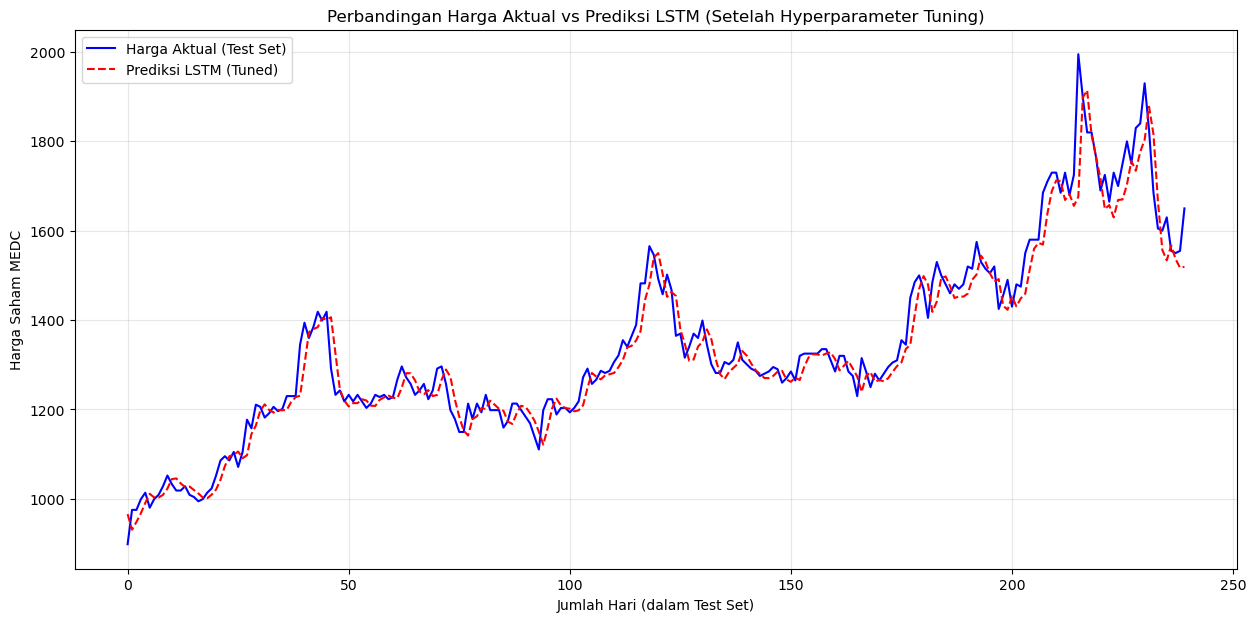

In [75]:
import matplotlib.pyplot as plt

# Menyiapkan plotting
plt.figure(figsize=(15, 7))

# Plot Data Aktual
plt.plot(y_test_inv_tuned, label='Harga Aktual (Test Set)', color='blue', linewidth=1.5)

# Plot Data Prediksi dari Model Terbaik
plt.plot(test_predict_tuned_inv, label='Prediksi LSTM (Tuned)', color='red', linestyle='--', linewidth=1.5)

plt.title('Perbandingan Harga Aktual vs Prediksi LSTM (Setelah Hyperparameter Tuning)')
plt.xlabel('Jumlah Hari (dalam Test Set)')
plt.ylabel('Harga Saham MEDC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Parameter Prediksi
num_prediction_days = 365
look_back = 60 # Sesuai dengan window yang digunakan saat training

# 2. Siapkan input awal (60 hari terakhir dari data historis)
last_60_days_scaled = data_scaled[-look_back:]
current_batch = last_60_days_scaled.reshape((1, look_back, 1))

future_predictions_scaled = []

print(f"Memulai prediksi untuk {num_prediction_days} hari ke depan...")

# 3. Loop Prediksi Iteratif
for i in range(num_prediction_days):
    # Prediksi satu langkah ke depan
    # verbose=0 agar tidak memenuhi output dengan log progress model.predict
    predicted_value_scaled = best_model.predict(current_batch, verbose=0)[0]
    future_predictions_scaled.append(predicted_value_scaled)

    # Update batch: hapus data tertua, masukkan hasil prediksi terbaru
    current_batch = np.append(current_batch[:, 1:, :], [[predicted_value_scaled]], axis=1)

# 4. Transformasi Balik ke Harga Asli
future_predictions_final = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

# 5. Buat Deret Tanggal Masa Depan
last_date = df['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=num_prediction_days, freq='D')

print("Prediksi selesai.")

Memulai prediksi untuk 365 hari ke depan...
Prediksi selesai.


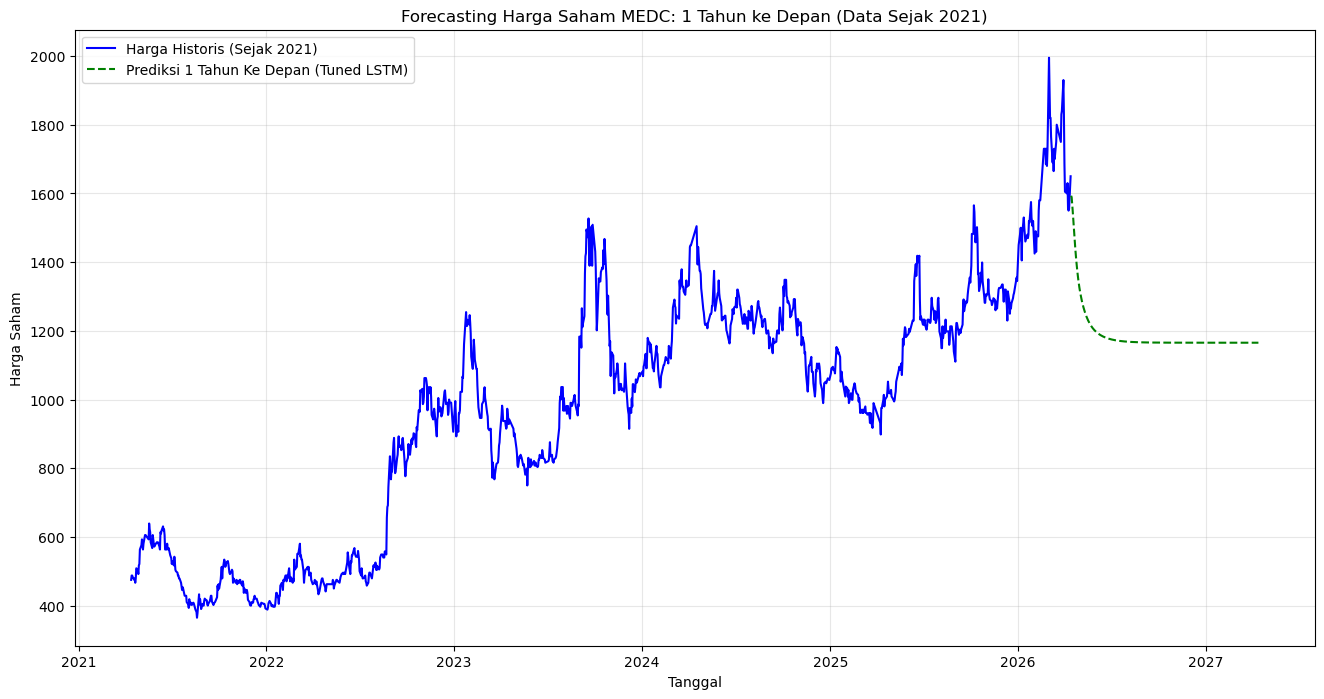

In [77]:
plt.figure(figsize=(16, 8))

# Filter data historis mulai dari tahun 2021
df_from_2021 = df[df['Date'] >= '2021-01-01']

# Plot Data Historis dari 2021
plt.plot(df_from_2021['Date'], df_from_2021['MEDC_Close'], label='Harga Historis (Sejak 2021)', color='blue')

# Plot Prediksi Masa Depan
plt.plot(future_dates, future_predictions_final, label='Prediksi 1 Tahun Ke Depan (Tuned LSTM)', color='green', linestyle='--')

plt.title('Forecasting Harga Saham MEDC: 1 Tahun ke Depan (Data Sejak 2021)')
plt.xlabel('Tanggal')
plt.ylabel('Harga Saham')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

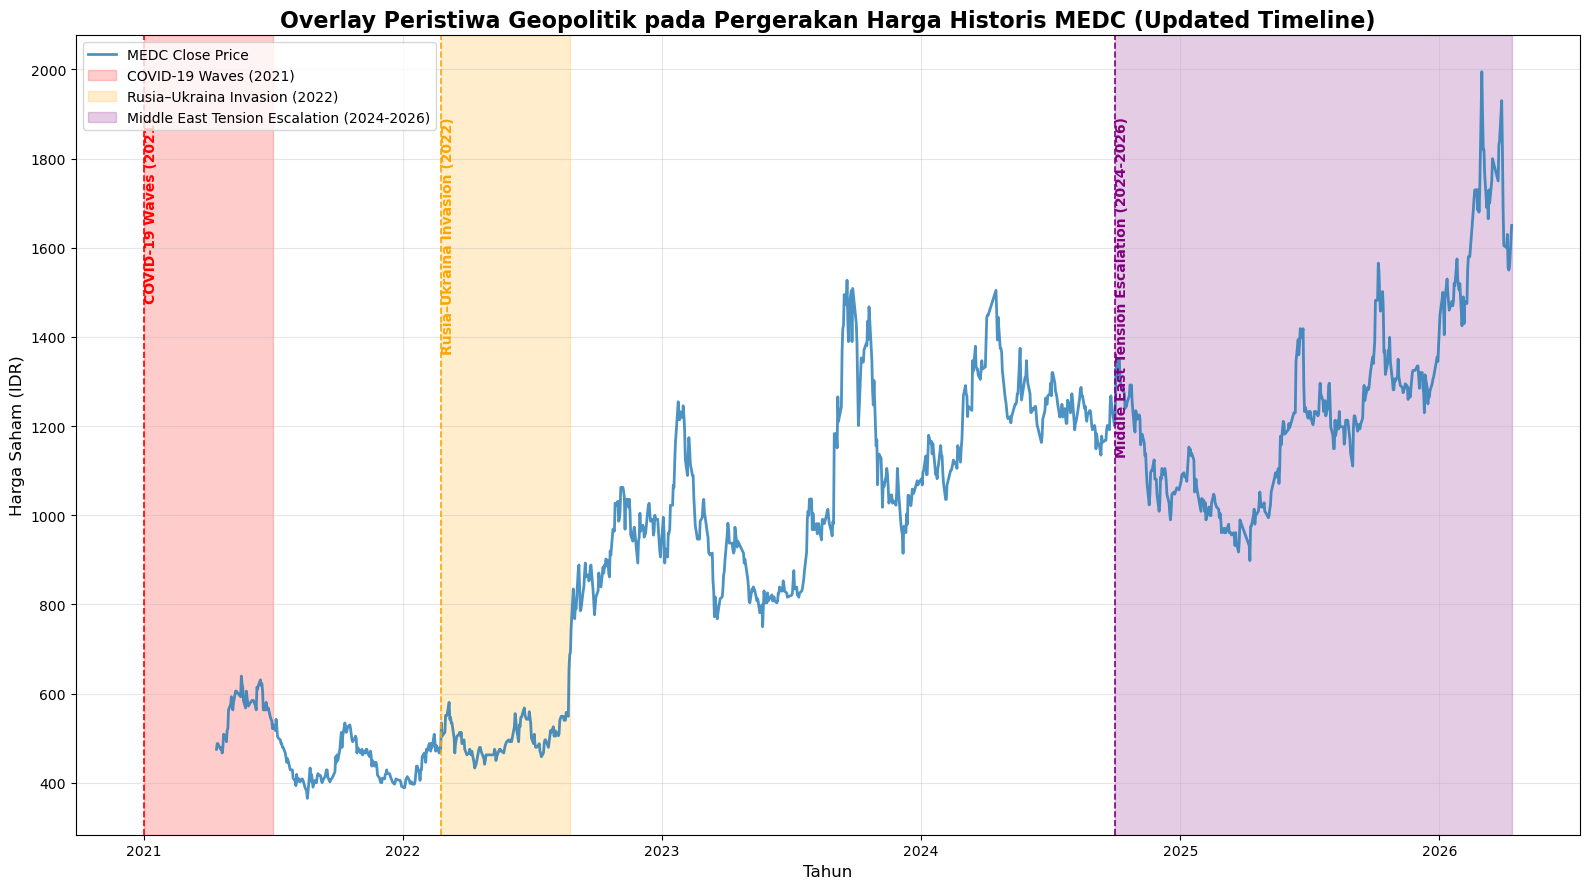

In [79]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Menyiapkan Canvas
plt.figure(figsize=(16, 9))

# 2. Plot Harga Historis MEDC dari data asli
plt.plot(df['Date'], df['MEDC_Close'], label='MEDC Close Price', color='#1f77b4', linewidth=2, alpha=0.8)

# 3. Definisi Event Geopolitik yang Diperbarui
events = [
    {'name': 'COVID-19 Waves (2021)', 'start': '2021-01-01', 'end': '2021-07-01', 'color': 'red'},
    {'name': 'Rusia–Ukraina Invasion (2022)', 'start': '2022-02-24', 'end': '2022-08-24', 'color': 'orange'},
    {'name': 'Middle East Tension Escalation (2024-2026)', 'start': '2024-10-01', 'end': '2026-04-13', 'color': 'purple'}
]

# 4. Overlay Event ke dalam Chart
for event in events:
    start_dt = pd.to_datetime(event['start'])
    end_dt = pd.to_datetime(event['end'])
    
    # Memastikan event berada dalam rentang data
    if start_dt <= df['Date'].max() and end_dt >= df['Date'].min():
        plt.axvspan(start_dt, end_dt, color=event['color'], alpha=0.2, label=event['name'])
        plt.axvline(x=start_dt, color=event['color'], linestyle='--', linewidth=1.2)
        
        # Penempatan teks label yang dinamis
        y_pos = df['MEDC_Close'].max() * 0.95
        plt.text(start_dt, y_pos, event['name'], rotation=90, 
                 verticalalignment='top', fontweight='bold', color=event['color'], fontsize=10)

# 5. Pengaturan Visual
plt.title('Overlay Peristiwa Geopolitik pada Pergerakan Harga Historis MEDC (Updated Timeline)', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Harga Saham (IDR)', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
import pandas as pd

# 1. Membuat DataFrame untuk hasil prediksi
# future_dates dan future_predictions_final sudah tersedia dari sel sebelumnya
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Close': future_predictions_final.flatten()
})

# 2. Simpan secara lokal
file_name = "medc_future_forecast.csv"
forecast_df.to_csv(file_name, index=False)
print(f"File '{file_name}' berhasil disimpan secara lokal.")

# 3. Unggah ke AWS S3
s3_path = "processed/medc_future_forecast.csv"
s3.upload_file(file_name, BUCKET_NAME, s3_path)
print(f"File berhasil diunggah ke S3: {BUCKET_NAME}/{s3_path}")

# Tampilkan 5 baris pertama prediksi
display(forecast_df.head())

File 'medc_future_forecast.csv' berhasil disimpan secara lokal.
File berhasil diunggah ke S3: medc-energy-forecasting/processed/medc_future_forecast.csv


,Date,Predicted_Close
0,2026-04-14,1593.300293
1,2026-04-15,1588.885986
2,2026-04-16,1571.251343
3,2026-04-17,1550.192749
4,2026-04-18,1527.752075
